In [16]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

In [17]:
df = pd.read_csv('cs-training.csv', index_col=0)


In [19]:
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [20]:
df = df[df['age'] > 18]
df = df[df['age'] < 100]
df = df[df['DebtRatio'] < 5000]
df = df[df['RevolvingUtilizationOfUnsecuredLines'] < 2]
df = df[df['MonthlyIncome'] < 500000]

df['TotalLatePayments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse'] +
    df['NumberOfTime60-89DaysPastDueNotWorse'] +
    df['NumberOfTimes90DaysLate']
)
df['IncomePerDependent'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)

X = df.drop('SeriousDlqin2yrs', axis=1)
y = df['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)


In [23]:
lr     = joblib.load('../models/logistic_regression.pkl')
rf     = joblib.load('../models/random_forest.pkl')
gb     = joblib.load('../models/gradient_boosting.pkl')
xgb    = joblib.load('../models/xgboost.pkl')
scaler = joblib.load('../models/scaler.pkl')

X_test_scaled = scaler.transform(X_test)

print("✅ Data rebuilt and models loaded!")
print("X_test shape:", X_test.shape)

✅ Data rebuilt and models loaded!
X_test shape: (29626, 12)


In [24]:
models = {
    'Logistic Regression': (lr,  scaler.transform(X_test)),
    'Random Forest':       (rf,  X_test),
    'Gradient Boosting':   (gb,  X_test),
    'XGBoost':             (xgb, X_test),
}

print(f"\n{'Model':<25} {'AUC-ROC':>9} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("─" * 75)




Model                       AUC-ROC  Accuracy  Precision   Recall       F1
───────────────────────────────────────────────────────────────────────────


In [25]:
all_results = {}

for name, (model, X) in models.items():
    y_pred    = model.predict(X)
    y_prob    = model.predict_proba(X)[:, 1]
    auc       = roc_auc_score(y_test, y_prob)
    acc       = (y_pred == y_test).mean()
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred, zero_division=0)
    f1        = f1_score(y_test, y_pred, zero_division=0)

    all_results[name] = {
        'auc': auc, 'acc': acc, 'precision': precision,
        'recall': recall, 'f1': f1,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    print(f"{name:<25} {auc:>9.4f} {acc:>9.4f} {precision:>10.4f} {recall:>8.4f} {f1:>8.4f}")

best = max(all_results, key=lambda x: all_results[x]['auc'])
print(f"\n🏆 Best Model: {best} with AUC = {all_results[best]['auc']:.4f}")

Logistic Regression          0.7988    0.7841     0.1867   0.6684   0.2919
Random Forest                0.9231    0.9459     0.5829   0.6577   0.6181
Gradient Boosting            0.8421    0.7889     0.2037   0.7459   0.3200
XGBoost                      0.8280    0.8242     0.2189   0.6389   0.3261

🏆 Best Model: Random Forest with AUC = 0.9231


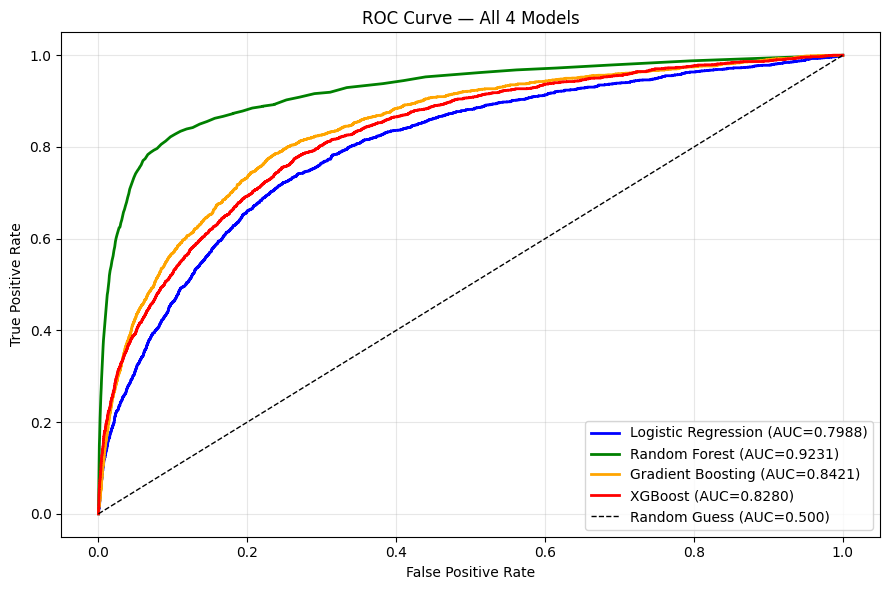

✅ ROC curve saved!


In [26]:
plt.figure(figsize=(9, 6))
colors = ['blue', 'green', 'orange', 'red']

for (name, results), color in zip(all_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, results['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results['auc']:.4f})",
             color=color, linewidth=2)

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Guess (AUC=0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — All 4 Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../models/roc_curve.png', dpi=150)
plt.show()
print("✅ ROC curve saved!")

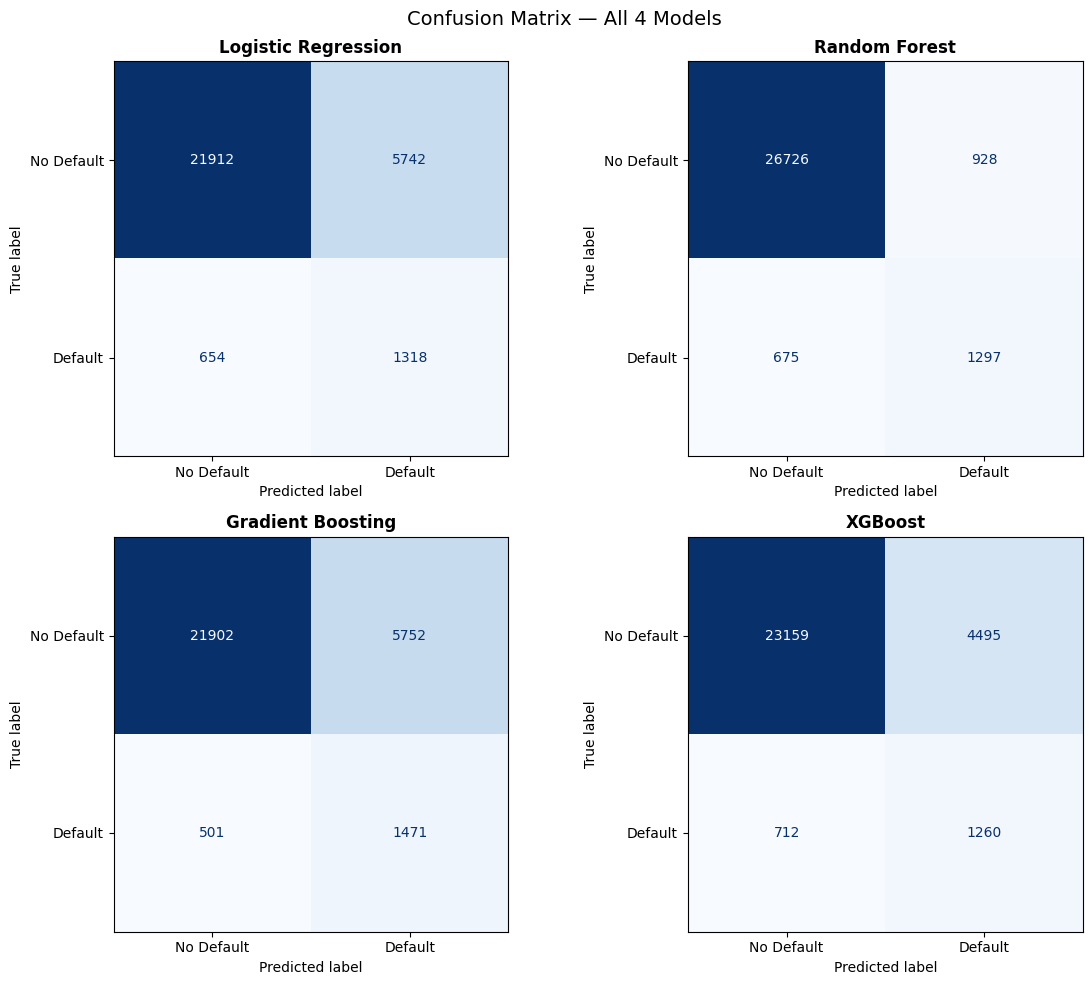

✅ Confusion matrices saved!


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, results) in enumerate(all_results.items()):
    cm = confusion_matrix(y_test, results['y_pred'])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Default', 'Default']
    )
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(name, fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrix — All 4 Models', fontsize=14)
plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved!")

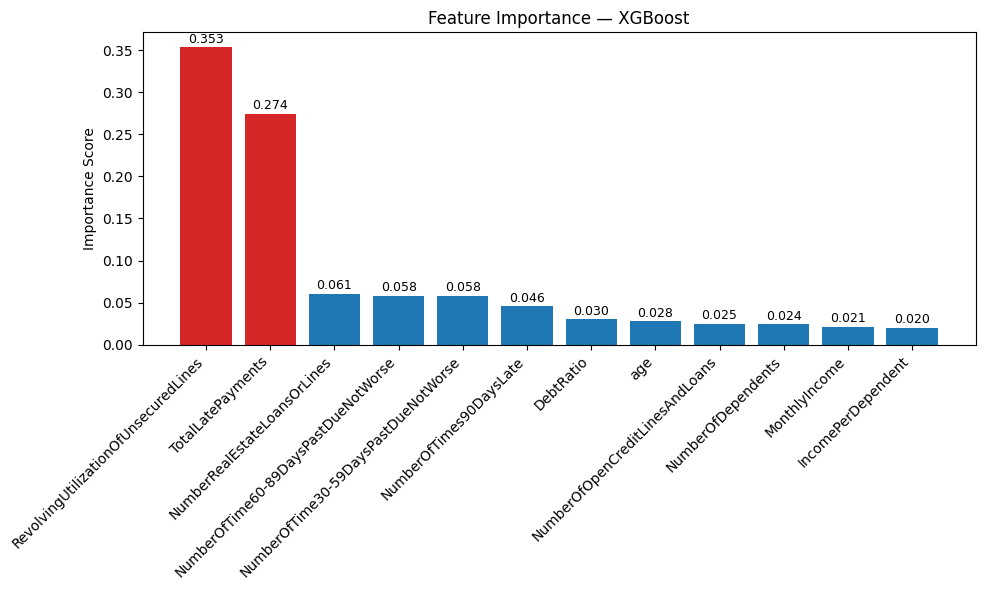

✅ Feature importance saved!

📊 Top 5 most important features:
  1. RevolvingUtilizationOfUnsecuredLines          0.3533
  2. TotalLatePayments                             0.2743
  3. NumberRealEstateLoansOrLines                  0.0609
  4. NumberOfTime60-89DaysPastDueNotWorse          0.0584
  5. NumberOfTime30-59DaysPastDueNotWorse          0.0582


In [28]:
feature_names = X_test.columns.tolist()
importances   = xgb.feature_importances_
sorted_idx    = np.argsort(importances)[::-1]
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_vals   = importances[sorted_idx]

plt.figure(figsize=(10, 6))
bars = plt.bar(range(len(sorted_vals)), sorted_vals,
               color=['#d62728' if v > 0.1 else '#1f77b4' for v in sorted_vals])
plt.xticks(range(len(sorted_names)), sorted_names, rotation=45, ha='right')
plt.ylabel('Importance Score')
plt.title('Feature Importance — XGBoost')
for bar, val in zip(bars, sorted_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../models/feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")

print("\n📊 Top 5 most important features:")
for i in range(5):
    print(f"  {i+1}. {sorted_names[i]:<45} {sorted_vals[i]:.4f}")

In [29]:
print("\n" + "="*65)
print("         FINAL MODEL EVALUATION SUMMARY")
print("="*65)
for name, results in all_results.items():
    print(f"\n  {name}")
    print(f"    AUC-ROC   : {results['auc']:.4f}")
    print(f"    Accuracy  : {results['acc']:.4f}")
    print(f"    Precision : {results['precision']:.4f}")
    print(f"    Recall    : {results['recall']:.4f}")
    print(f"    F1 Score  : {results['f1']:.4f}")
print("\n" + "="*65)
print(f"  🏆 BEST MODEL : {best}")
print(f"  🎯 BEST AUC   : {all_results[best]['auc']:.4f}")
print("="*65)


         FINAL MODEL EVALUATION SUMMARY

  Logistic Regression
    AUC-ROC   : 0.7988
    Accuracy  : 0.7841
    Precision : 0.1867
    Recall    : 0.6684
    F1 Score  : 0.2919

  Random Forest
    AUC-ROC   : 0.9231
    Accuracy  : 0.9459
    Precision : 0.5829
    Recall    : 0.6577
    F1 Score  : 0.6181

  Gradient Boosting
    AUC-ROC   : 0.8421
    Accuracy  : 0.7889
    Precision : 0.2037
    Recall    : 0.7459
    F1 Score  : 0.3200

  XGBoost
    AUC-ROC   : 0.8280
    Accuracy  : 0.8242
    Precision : 0.2189
    Recall    : 0.6389
    F1 Score  : 0.3261

  🏆 BEST MODEL : Random Forest
  🎯 BEST AUC   : 0.9231


In [30]:
results_df = pd.DataFrame({
    'Model':     list(all_results.keys()),
    'AUC_ROC':   [all_results[m]['auc']       for m in all_results],
    'Accuracy':  [all_results[m]['acc']        for m in all_results],
    'Precision': [all_results[m]['precision']  for m in all_results],
    'Recall':    [all_results[m]['recall']     for m in all_results],
    'F1_Score':  [all_results[m]['f1']         for m in all_results],
}).round(4).sort_values('AUC_ROC', ascending=False)

results_df.to_csv('../models/evaluation_results.csv', index=False)
print("\n✅ Results saved to models/evaluation_results.csv")
print(results_df.to_string(index=False))


✅ Results saved to models/evaluation_results.csv
              Model  AUC_ROC  Accuracy  Precision  Recall  F1_Score
      Random Forest   0.9231    0.9459     0.5829  0.6577    0.6181
  Gradient Boosting   0.8421    0.7889     0.2037  0.7459    0.3200
            XGBoost   0.8280    0.8242     0.2189  0.6389    0.3261
Logistic Regression   0.7988    0.7841     0.1867  0.6684    0.2919
